
# Text-to-Image — Hugging Face Inference API + LangChain

# ============================================================

In [8]:
# CELL 1 — install deps
!pip install huggingface_hub langchain-core -q

In [9]:
# CELL 2 — credentials
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")


In [10]:
# CELL 3 — HF client + LangChain tool
import io

from huggingface_hub import InferenceClient
from langchain_core.tools import tool
from IPython.display import display

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"  # koi bhi text-to-image model daal sakte ho

hf_client = InferenceClient(model=MODEL_ID, token=os.environ["HF_TOKEN"])


@tool
def generate_image(prompt: str, negative_prompt: str = ""):
    """Generate an image from a text prompt using a Hugging Face
    text-to-image model. Returns a PIL Image object."""

    image = hf_client.text_to_image(
        prompt,
        negative_prompt=negative_prompt or None,
    )
    return image



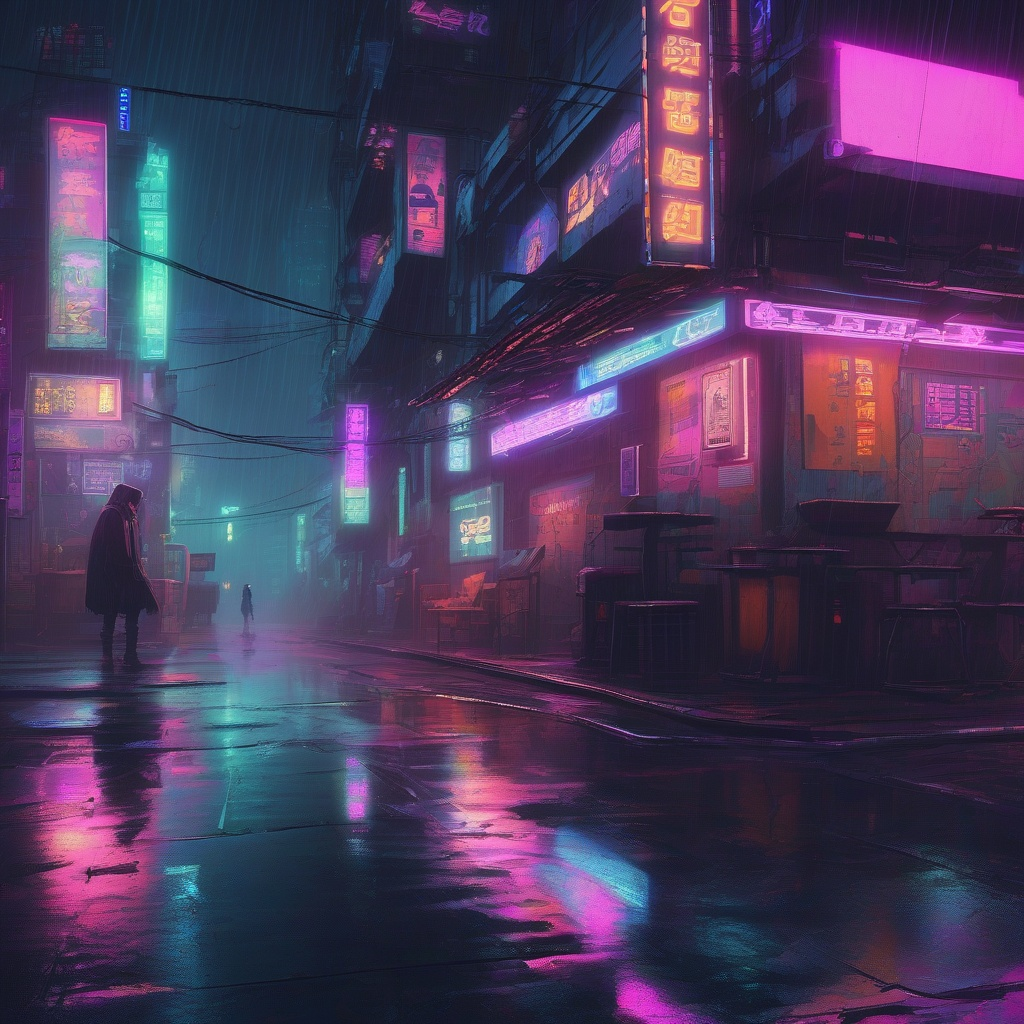

Saved as generated.png


In [11]:

# CELL 4 — run it
prompt = "A cyberpunk city street at night, neon lights, rain"  # <-- prompt
negative_prompt = ""  # optional

img = generate_image.invoke({"prompt": prompt, "negative_prompt": negative_prompt})

display(img)
img.save("generated.png")
print("Saved as generated.png")

# to download from colab:
# from google.colab import files
# files.download("generated.png")

# Text-to-Image — Hugging Face minimal version

In [ ]:
# CELL 1 — install deps
!pip install huggingface_hub langchain-core -q

In [ ]:
# CELL 2 — credentials
from google.colab import userdata
import os

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")

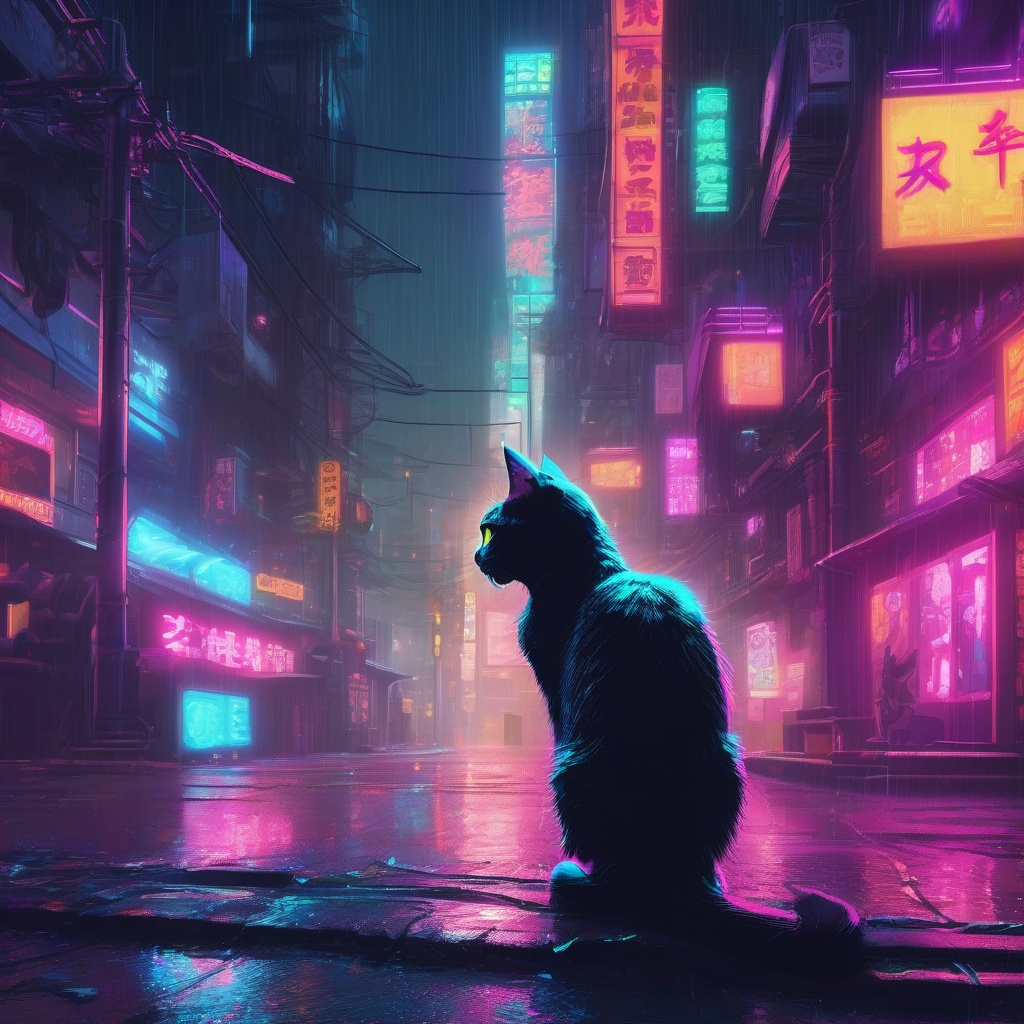

In [12]:
from huggingface_hub import InferenceClient

MODEL_ID = "stabilityai/stable-diffusion-xl-base-1.0"  # any text-to-image model

hf_client = InferenceClient(model=MODEL_ID, token=os.environ["HF_TOKEN"])

# CELL 3
prompt = "a cat on cyberpunk city street at night, neon lights, rain, highly detailed"

img = hf_client.text_to_image(prompt)
img.save("generated.png")
img
